#### Import the Libraries

In [1]:
import pickle
import datetime

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense 
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
from sklearn.metrics import confusion_matrix, classification_report, f1_score

#### Load the Dataset

In [2]:
dataset = pd.read_csv('../data/churn-modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Null Check
dataset.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
# Class Imbalance Check
print(dataset['Exited'].value_counts(normalize=True) * 100)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


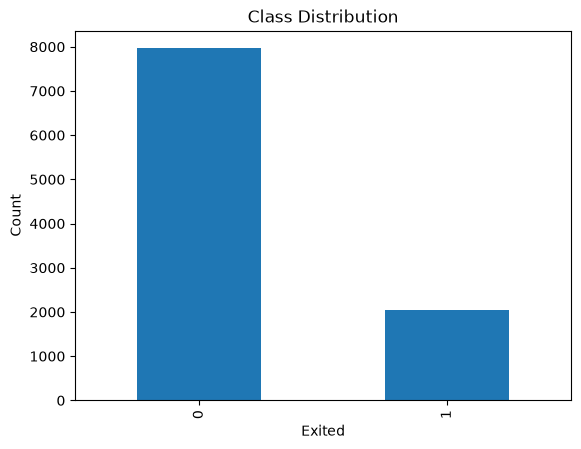

In [5]:
dataset['Exited'].value_counts().plot(kind='bar')
plt.xlabel("Exited")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

#### Preprocess the Data

##### Drop irrelevant columns

In [6]:
dataset = dataset.drop(["RowNumber", "CustomerId", "Surname"], axis = 1)
dataset.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# Separate features and target
X = dataset.drop('Exited', axis=1)
y = dataset['Exited']

##### Encode Categorical Variable

##### LabelEncode 'Gender' Column

In [8]:
le_gender = LabelEncoder()
X['Gender'] = le_gender.fit_transform(X['Gender'])
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,0,42,2,0.00,1,1,1,101348.88
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58
2,502,France,0,42,8,159660.80,3,1,0,113931.57
3,699,France,0,39,1,0.00,2,0,0,93826.63
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64
9996,516,France,1,35,10,57369.61,1,1,1,101699.77
9997,709,France,0,36,7,0.00,1,0,1,42085.58
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52


##### OneHotEncode 'Geography' Column

In [9]:
ct_geo = ColumnTransformer(transformers=[('encode', OneHotEncoder(sparse_output=False), ['Geography'])], remainder="passthrough")
X = pd.DataFrame(ct_geo.fit_transform(X), columns=ct_geo.get_feature_names_out())
X

,encode__Geography_France,encode__Geography_Germany,encode__Geography_Spain,remainder__CreditScore,remainder__Gender,remainder__Age,remainder__Tenure,remainder__Balance,remainder__NumOfProducts,remainder__HasCrCard,remainder__IsActiveMember,remainder__EstimatedSalary
0,1.0,0.0,0.0,619.0,0.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88
1,0.0,0.0,1.0,608.0,0.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58
2,1.0,0.0,0.0,502.0,0.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57
3,1.0,0.0,0.0,699.0,0.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63
4,0.0,0.0,1.0,850.0,0.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.0,0.0,0.0,771.0,1.0,39.0,5.0,0.00,2.0,1.0,0.0,96270.64
9996,1.0,0.0,0.0,516.0,1.0,35.0,10.0,57369.61,1.0,1.0,1.0,101699.77
9997,1.0,0.0,0.0,709.0,0.0,36.0,7.0,0.00,1.0,0.0,1.0,42085.58
9998,0.0,1.0,0.0,772.0,1.0,42.0,3.0,75075.31,2.0,1.0,0.0,92888.52


In [10]:
X.columns = [col.split("__")[-1] for col in X.columns]
X

,Geography_France,Geography_Germany,Geography_Spain,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,1.0,0.0,0.0,619.0,0.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88
1,0.0,0.0,1.0,608.0,0.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58
2,1.0,0.0,0.0,502.0,0.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57
3,1.0,0.0,0.0,699.0,0.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63
4,0.0,0.0,1.0,850.0,0.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.0,0.0,0.0,771.0,1.0,39.0,5.0,0.00,2.0,1.0,0.0,96270.64
9996,1.0,0.0,0.0,516.0,1.0,35.0,10.0,57369.61,1.0,1.0,1.0,101699.77
9997,1.0,0.0,0.0,709.0,0.0,36.0,7.0,0.00,1.0,0.0,1.0,42085.58
9998,0.0,1.0,0.0,772.0,1.0,42.0,3.0,75075.31,2.0,1.0,0.0,92888.52


##### Split Data into Train and Test Set

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0, stratify=y)

##### Scale the Features

In [12]:
# Scaling the X_train and X_test 
sc = StandardScaler()
X_train.iloc[:, 3:] = sc.fit_transform(X_train.iloc[:, 3:])
X_test.iloc[:, 3:] = sc.transform(X_test.iloc[:, 3:])

##### Pickle Fitted Encoders and Scalers

In [13]:
with open("../artifacts/label_encoder.pkl", "wb") as file:
    pickle.dump(le_gender, file)

with open("../artifacts/onehot_encoder.pkl", "wb") as file:
    pickle.dump(ct_geo, file)

with open("../artifacts/standard_scaler.pkl", "wb") as file:
    pickle.dump(sc, file)

##### ANN Implementation

In [14]:
# Build ANN Model
model = Sequential(
    [
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ]
)

In [15]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Compile Model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', 
    Precision(name='precision'), Recall(name='recall'), AUC(name='roc_auc')])

In [17]:
# Setup Tensorboard
log_dir = '../logs/fit/' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
tensorflow_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [18]:
# Setup Early Stopping
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

In [19]:
# Setup LR Scheduler
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       
    patience=3,       
    min_lr=1e-6,
    verbose=1
)

In [20]:
# Train the Model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, 
                    callbacks=[tensorflow_callback, early_stopping_callback, lr_scheduler])

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8050 - loss: 0.4494 - precision: 0.5643 - recall: 0.1883 - roc_auc: 0.7314 - val_accuracy: 0.8410 - val_loss: 0.3945 - val_precision: 0.7633 - val_recall: 0.3170 - val_roc_auc: 0.8115 - learning_rate: 0.0010
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8471 - loss: 0.3722 - precision: 0.7408 - recall: 0.3840 - roc_auc: 0.8322 - val_accuracy: 0.8545 - val_loss: 0.3634 - val_precision: 0.8258 - val_recall: 0.3612 - val_roc_auc: 0.8373 - learning_rate: 0.0010
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8580 - loss: 0.3474 - precision: 0.7584 - recall: 0.4448 - roc_auc: 0.8536 - val_accuracy: 0.8555 - val_loss: 0.3503 - val_precision: 0.7731 - val_recall: 0.4103 - val_roc_auc: 0.8506 - learning_rate: 0.0010
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8634 - loss: 0.3389 - precision: 0.7777 - recall: 0.4613 - roc_auc: 0.8611 - val_accuracy: 0.8550 - val_loss

In [21]:
# Save the Model
model.save('../models/ann_model.keras')

In [22]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.4)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(f1_score(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step
[[1486  107]
 [ 191  216]]
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1593
           1       0.67      0.53      0.59       407

    accuracy                           0.85      2000
   macro avg       0.78      0.73      0.75      2000
weighted avg       0.84      0.85      0.84      2000

0.5917808219178082


In [25]:
# Load the TensorBoard Extension
%reload_ext tensorboard

In [26]:
# Visualize the Logs
%tensorboard --logdir $log_dir

Reusing TensorBoard on port 6006 (pid 22864), started 0:00:13 ago. (Use '!kill 22864' to kill it.)